# PROYEK UAS DATA MINING LANJUT
## Prediksi Status Gizi dan Risiko Stunting Balita Menggunakan Machine Learning

Dataset: Stunting Toddler (Balita) Detection (Kaggle) https://www.kaggle.com/datasets/rendiputra/stunting-balita-detection-121k-rows

Alur notebook ini mengikuti pembagian tugas:
1. Nizellya Salfani (2301010014): data understanding dan audit data
2. Anggi Rahmawati (2301010001): cleaning dan preprocessing
3. Daffa Dhiya Ulhaq (2301010024): exploratory data analysis
4. Fahmi Syarief H. (2301010003): training model awal
5. Made Arya Sutha Wijaya (2301010030): hyperparameter tuning, ensemble learning, evaluasi, dan export model
6. Ahmad Jul Hadi (2301010019): deployment Streamlit


## ANGGOTA 1 - NIZEL
### Data Understanding dan Data Audit

Bagian ini memasukkan dataset dan mengecek kondisi awal data.


In [ ]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')


In [ ]:
# Load dataset dari lokal jika ada, jika tidak gunakan Google Drive.
local_path = 'drive-download-20260608T020045Z-3-001/dataset/data_balita.csv'
colab_path = 'data_balita.csv'

if os.path.exists(local_path):
    dataset_path = local_path
elif os.path.exists(colab_path):
    dataset_path = colab_path
else:
    try:
        import gdown
    except ImportError:
        !pip install -q gdown
        import gdown

    file_id = '1UXupD-c6It0IF-PKMRuLWIzeJ-LM_6uL'
    url = f'https://drive.google.com/uc?id={file_id}'
    dataset_path = colab_path
    gdown.download(url, dataset_path, quiet=False)

df = pd.read_csv(dataset_path)
print('Dataset berhasil dimuat dari:', dataset_path)
df.head()


Downloading...
From: https://drive.google.com/uc?id=1UXupD-c6It0IF-PKMRuLWIzeJ-LM_6uL
To: /content/data_balita.csv
100%|██████████| 3.30M/3.30M [00:00<00:00, 82.0MB/s]

Dataset berhasil dimuat dari: data_balita.csv


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted


In [ ]:
print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
print('\nNama kolom:')
print(df.columns.tolist())


Jumlah baris: 120999
Jumlah kolom: 4

Nama kolom:
['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)', 'Status Gizi']


In [ ]:
print('Tipe data setiap kolom:')
print(df.dtypes)

print('\nInformasi dataset:')
df.info()


Tipe data setiap kolom:
Umur (bulan)           int64
Jenis Kelamin         object
Tinggi Badan (cm)    float64
Status Gizi           object
dtype: object

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120999 entries, 0 to 120998
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Umur (bulan)       120999 non-null  int64  
 1   Jenis Kelamin      120999 non-null  object 
 2   Tinggi Badan (cm)  120999 non-null  float64
 3   Status Gizi        120999 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.7+ MB


In [ ]:
print('Missing value awal:')
print(df.isnull().sum())

print('\nJumlah data duplikat awal:', df.duplicated().sum())


Missing value awal:
Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
Status Gizi          0
dtype: int64

Jumlah data duplikat awal: 81574


In [ ]:
print('Distribusi target Status Gizi:')
print(df['Status Gizi'].value_counts())

print('\nPersentase target Status Gizi:')
print((df['Status Gizi'].value_counts(normalize=True) * 100).round(2))


Distribusi target Status Gizi:
Status Gizi
normal              67755
severely stunted    19869
tinggi              19560
stunted             13815
Name: count, dtype: int64

Persentase target Status Gizi:
Status Gizi
normal              56.00
severely stunted    16.42
tinggi              16.17
stunted             11.42
Name: proportion, dtype: float64


In [ ]:
max_class = df['Status Gizi'].value_counts().max()
min_class = df['Status Gizi'].value_counts().min()
imbalance_ratio = max_class / min_class

print('Rasio kelas terbesar terhadap terkecil:', round(imbalance_ratio, 2))
if imbalance_ratio > 2:
    print('Dataset memiliki indikasi imbalance.')
else:
    print('Distribusi kelas relatif seimbang.')


Rasio kelas terbesar terhadap terkecil: 4.9
Dataset memiliki indikasi imbalance.


In [ ]:
feature_description = {
    'Umur (bulan)': 'Usia balita dalam bulan',
    'Jenis Kelamin': 'Jenis kelamin balita',
    'Tinggi Badan (cm)': 'Tinggi badan balita dalam sentimeter',
    'Status Gizi': 'Label status gizi balita'
}

for fitur, deskripsi in feature_description.items():
    print(f'{fitur}: {deskripsi}')


Umur (bulan): Usia balita dalam bulan
Jenis Kelamin: Jenis kelamin balita
Tinggi Badan (cm): Tinggi badan balita dalam sentimeter
Status Gizi: Label status gizi balita


In [ ]:
for col in df.columns:
    print(f'\nKolom: {col}')
    print('Jumlah nilai unik:', df[col].nunique())
    print(df[col].drop_duplicates().head(10).tolist())



Kolom: Umur (bulan)
Jumlah nilai unik: 61
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Kolom: Jenis Kelamin
Jumlah nilai unik: 2
['laki-laki', 'perempuan']

Kolom: Tinggi Badan (cm)
Jumlah nilai unik: 6800
[44.5919732943438, 56.7052033668847, 46.8633575967919, 47.5080256315438, 42.7434938911793, 44.2577186391463, 59.5725227366786, 42.7017961514634, 45.2517789938352, 57.201961037402]

Kolom: Status Gizi
Jumlah nilai unik: 4
['stunted', 'tinggi', 'normal', 'severely stunted']


## ANGGOTA 2 - ANGGI
### Data Cleaning dan Preprocessing

Bagian ini membersihkan data, encoding label, split data, scaling, dan SMOTE. SMOTE diterapkan hanya pada data latih agar data test tetap mewakili kondisi asli.


In [ ]:
print('Missing value sebelum cleaning:')
print(df.isnull().sum())

df_clean = df.copy()
df_clean['Jenis Kelamin'] = df_clean['Jenis Kelamin'].astype(str).str.strip().str.lower()
df_clean['Status Gizi'] = df_clean['Status Gizi'].astype(str).str.strip().str.lower()

numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print('\nMissing value setelah imputasi:')
print(df_clean.isnull().sum())


Missing value sebelum cleaning:
Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
Status Gizi          0
dtype: int64

Missing value setelah imputasi:
Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
Status Gizi          0
dtype: int64


In [ ]:
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
rows_after = len(df_clean)

print('Jumlah data sebelum hapus duplikat:', rows_before)
print('Jumlah data setelah hapus duplikat:', rows_after)
print('Jumlah duplikat terhapus:', rows_before - rows_after)
print('Sisa duplikat:', df_clean.duplicated().sum())


Jumlah data sebelum hapus duplikat: 120999
Jumlah data setelah hapus duplikat: 39425
Jumlah duplikat terhapus: 81574
Sisa duplikat: 0


In [ ]:
valid_gender = ['laki-laki', 'perempuan']
valid_status = ['normal', 'stunted', 'severely stunted', 'tinggi']

rows_before_validation = len(df_clean)
df_clean = df_clean[
    df_clean['Umur (bulan)'].between(0, 60) &
    df_clean['Tinggi Badan (cm)'].between(40, 130) &
    df_clean['Jenis Kelamin'].isin(valid_gender) &
    df_clean['Status Gizi'].isin(valid_status)
].reset_index(drop=True)

print('Baris sebelum validasi range:', rows_before_validation)
print('Baris setelah validasi range:', len(df_clean))
print('Baris terhapus:', rows_before_validation - len(df_clean))


Baris sebelum validasi range: 39425
Baris setelah validasi range: 39425
Baris terhapus: 0


In [ ]:
outlier_mask = pd.Series(False, index=df_clean.index)

for col in ['Umur (bulan)', 'Tinggi Badan (cm)']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    col_outlier = ~df_clean[col].between(lower_bound, upper_bound)
    outlier_mask = outlier_mask | col_outlier

    print(f'{col}')
    print('Batas bawah:', round(lower_bound, 2))
    print('Batas atas :', round(upper_bound, 2))
    print('Jumlah outlier:', int(col_outlier.sum()))
    print()

rows_before_outlier = len(df_clean)
df_clean = df_clean[~outlier_mask].reset_index(drop=True)

print('Jumlah data sebelum handling outlier:', rows_before_outlier)
print('Jumlah data setelah handling outlier:', len(df_clean))
print('Data terhapus sebagai outlier:', rows_before_outlier - len(df_clean))


Umur (bulan)
Batas bawah: -42.5
Batas atas : 97.5
Jumlah outlier: 0

Tinggi Badan (cm)
Batas bawah: 29.05
Batas atas : 143.85
Jumlah outlier: 0

Jumlah data sebelum handling outlier: 39425
Jumlah data setelah handling outlier: 39425
Data terhapus sebagai outlier: 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

le_gender = LabelEncoder()
le_status = LabelEncoder()

df_model = df_clean.copy()
df_model['Jenis Kelamin'] = le_gender.fit_transform(df_model['Jenis Kelamin'])
df_model['Status Gizi'] = le_status.fit_transform(df_model['Status Gizi'])

X = df_model.drop('Status Gizi', axis=1)
y = df_model['Status Gizi']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Label gender:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('Label status:', dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))
print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)


Label gender: {'laki-laki': np.int64(0), 'perempuan': np.int64(1)}
Label status: {'normal': np.int64(0), 'severely stunted': np.int64(1), 'stunted': np.int64(2), 'tinggi': np.int64(3)}
Shape X_train: (31540, 3)
Shape X_test : (7885, 3)


In [ ]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Contoh data training setelah scaling:')
X_train_scaled.head()


Contoh data training setelah scaling:


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm)
26727,0.662405,-1.016367,0.219334
24481,0.454591,-1.016367,-0.231430
36517,1.441709,0.983896,0.695422
9595,-0.948157,-1.016367,-0.996210
15512,-0.376667,0.983896,0.092715


In [ ]:
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install -q imbalanced-learn
    from imblearn.over_sampling import SMOTE

print('Distribusi target sebelum SMOTE pada data latih:')
print(pd.Series(y_train).value_counts().sort_index())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_res = pd.Series(y_train_res, name='Status Gizi')

print('\nDistribusi target setelah SMOTE pada data latih:')
print(y_train_res.value_counts().sort_index())
print('\nShape X_train_res:', X_train_res.shape)
print('Shape X_test_scaled:', X_test_scaled.shape)


Distribusi target sebelum SMOTE pada data latih:
Status Gizi
0    17211
1     5216
2     3534
3     5579
Name: count, dtype: int64

Distribusi target setelah SMOTE pada data latih:
Status Gizi
0    17211
1    17211
2    17211
3    17211
Name: count, dtype: int64

Shape X_train_res: (68844, 3)
Shape X_test_scaled: (7885, 3)


In [ ]:
print('Cek missing value fitur latih:', X_train_res.isnull().sum().sum())
print('Cek missing value fitur test :', X_test_scaled.isnull().sum().sum())
print('\nTipe data fitur latih:')
print(X_train_res.dtypes)

train_preprocessed = X_train_res.copy()
train_preprocessed['Status Gizi'] = y_train_res
train_preprocessed.to_csv('hasil_preprocessing_stunting_train.csv', index=False)

print('\nFile preprocessing train disimpan: hasil_preprocessing_stunting_train.csv')


Cek missing value fitur latih: 0
Cek missing value fitur test : 0

Tipe data fitur latih:
Umur (bulan)         float64
Jenis Kelamin        float64
Tinggi Badan (cm)    float64
dtype: object

File preprocessing train disimpan: hasil_preprocessing_stunting_train.csv


## ANGGOTA 3 - DAPPA
### Exploratory Data Analysis

EDA menggunakan `df_clean`, yaitu data yang sudah dibersihkan tetapi label kategorinya masih mudah dibaca.


In [ ]:
df_eda = df_clean.copy()

print('Lima data teratas untuk EDA:')
df_eda.head()


Lima data teratas untuk EDA:


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted


In [ ]:
print('Info data EDA:')
df_eda.info()

print('\nMissing value data EDA:')
print(df_eda.isnull().sum())


Info data EDA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39425 entries, 0 to 39424
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Umur (bulan)       39425 non-null  int64  
 1   Jenis Kelamin      39425 non-null  object 
 2   Tinggi Badan (cm)  39425 non-null  float64
 3   Status Gizi        39425 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.2+ MB

Missing value data EDA:
Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
Status Gizi          0
dtype: int64


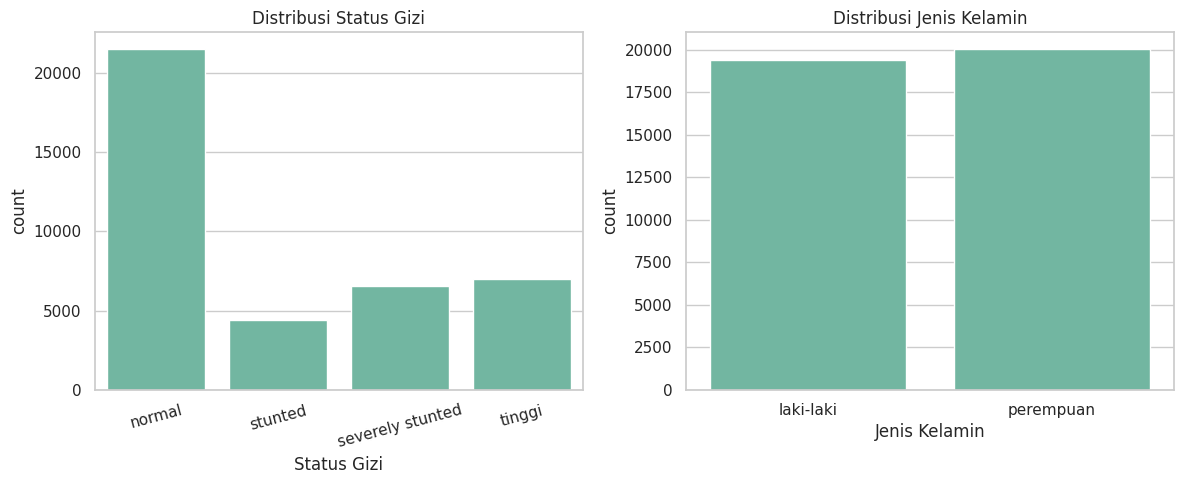

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_eda, x='Status Gizi', order=valid_status)
plt.title('Distribusi Status Gizi')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.countplot(data=df_eda, x='Jenis Kelamin', order=valid_gender)
plt.title('Distribusi Jenis Kelamin')

plt.tight_layout()
plt.show()


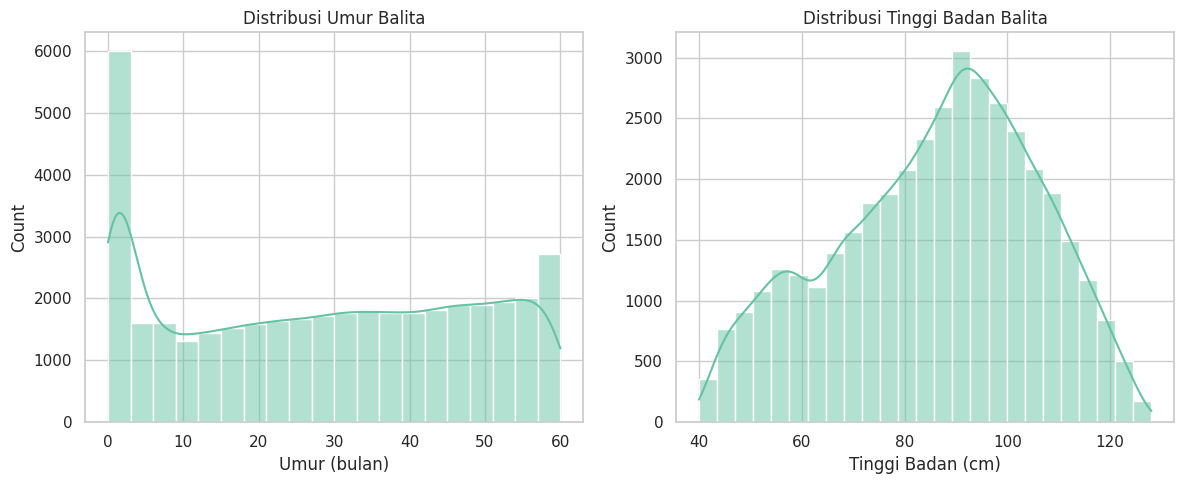

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_eda['Umur (bulan)'], bins=20, kde=True)
plt.title('Distribusi Umur Balita')

plt.subplot(1, 2, 2)
sns.histplot(df_eda['Tinggi Badan (cm)'], bins=25, kde=True)
plt.title('Distribusi Tinggi Badan Balita')

plt.tight_layout()
plt.show()


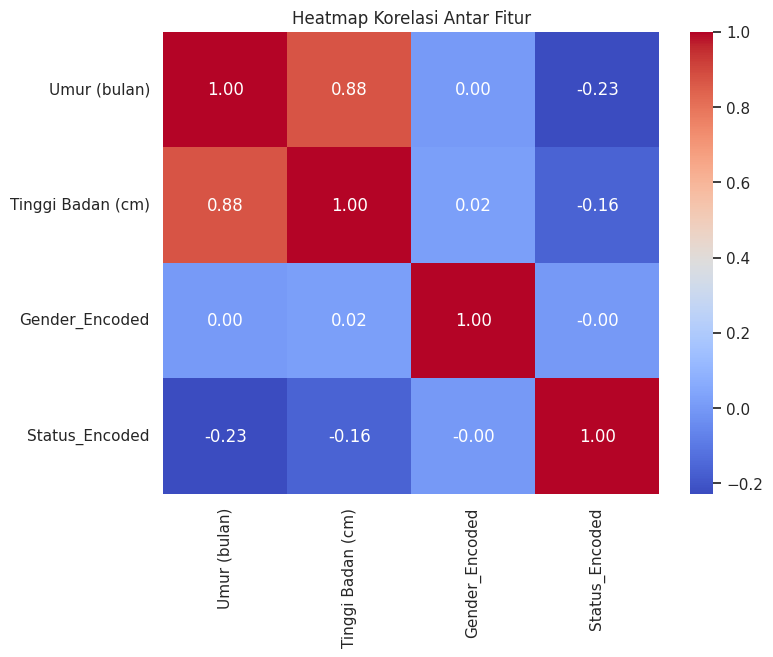

In [ ]:
df_corr = df_eda.copy()
df_corr['Gender_Encoded'] = df_corr['Jenis Kelamin'].map({'perempuan': 0, 'laki-laki': 1})
df_corr['Status_Encoded'] = df_corr['Status Gizi'].map({label: idx for idx, label in enumerate(valid_status)})

corr_matrix = df_corr[['Umur (bulan)', 'Tinggi Badan (cm)', 'Gender_Encoded', 'Status_Encoded']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


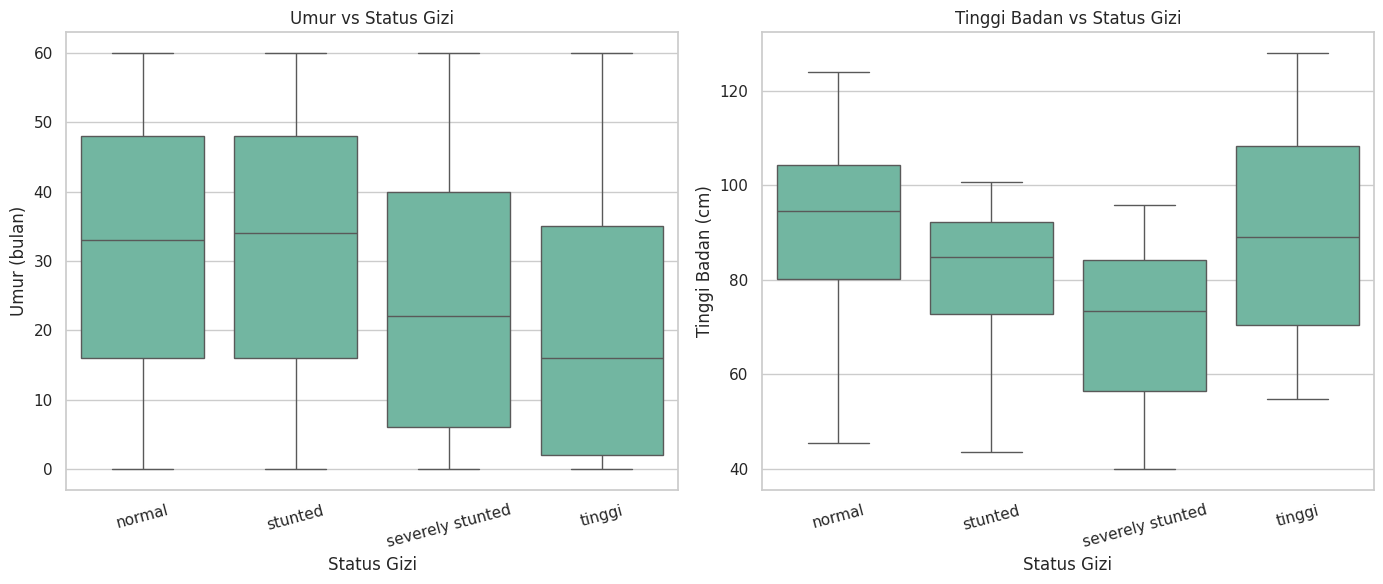

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_eda, x='Status Gizi', y='Umur (bulan)', order=valid_status)
plt.title('Umur vs Status Gizi')
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_eda, x='Status Gizi', y='Tinggi Badan (cm)', order=valid_status)
plt.title('Tinggi Badan vs Status Gizi')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


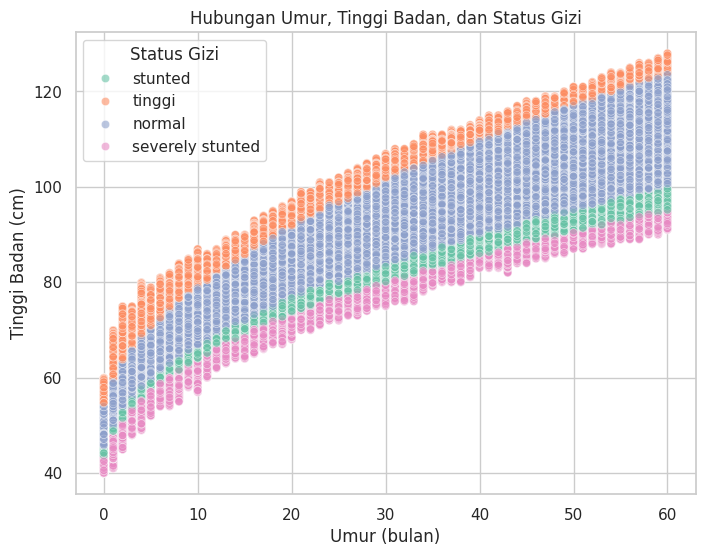

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_eda,
    x='Umur (bulan)',
    y='Tinggi Badan (cm)',
    hue='Status Gizi',
    alpha=0.6
)
plt.title('Hubungan Umur, Tinggi Badan, dan Status Gizi')
plt.show()


## ANGGOTA 4 - FAHMI
### Model Training Awal

Bagian ini melatih tiga model dasar: Logistic Regression, Decision Tree, dan Random Forest. Data training yang digunakan adalah hasil preprocessing Anggi.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print('Fitur yang digunakan:', X_train_res.columns.tolist())
print('Jumlah data training setelah SMOTE:', X_train_res.shape[0])
print('Jumlah data testing:', X_test_scaled.shape[0])


Fitur yang digunakan: ['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)']
Jumlah data training setelah SMOTE: 68844
Jumlah data testing: 7885


In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_res, y_train_res)
log_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)

print('Accuracy Logistic Regression:', round(log_acc, 4))


Accuracy Logistic Regression: 0.6344


In [ ]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_res, y_train_res)
tree_pred = tree_model.predict(X_test_scaled)
tree_acc = accuracy_score(y_test, tree_pred)

print('Accuracy Decision Tree:', round(tree_acc, 4))


Accuracy Decision Tree: 0.988


In [ ]:
forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
forest_model.fit(X_train_res, y_train_res)
forest_pred = forest_model.predict(X_test_scaled)
forest_acc = accuracy_score(y_test, forest_pred)

print('Accuracy Random Forest:', round(forest_acc, 4))


Accuracy Random Forest: 0.9914


In [ ]:
baseline_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_acc, tree_acc, forest_acc]
}).sort_values(by='Accuracy', ascending=False)

baseline_results


,Model,Accuracy
2,Random Forest,0.991376
1,Decision Tree,0.987952
0,Logistic Regression,0.634369


## ANGGOTA 5 - SUTA
### Hyperparameter Tuning, Ensemble Learning, Evaluasi, dan Export Model

Bagian ini melakukan tuning dengan GridSearchCV, menambahkan ensemble learning, menghitung accuracy, precision, recall, F1-score, confusion matrix, lalu memilih model terbaik.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier

print('Data siap untuk tuning:')
print('X_train_res:', X_train_res.shape)
print('X_test_scaled:', X_test_scaled.shape)


Data siap untuk tuning:
X_train_res: (68844, 3)
X_test_scaled: (7885, 3)


In [ ]:
print('=== Tuning Logistic Regression ===')

lr_params = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
lr_grid.fit(X_train_res, y_train_res)

best_lr = lr_grid.best_estimator_
print('Best parameter Logistic Regression:', lr_grid.best_params_)
print('Best CV F1-macro:', round(lr_grid.best_score_, 4))


=== Tuning Logistic Regression ===
Best parameter Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Best CV F1-macro: 0.6911


In [ ]:
print('=== Tuning Decision Tree ===')

dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
dt_grid.fit(X_train_res, y_train_res)

best_dt = dt_grid.best_estimator_
print('Best parameter Decision Tree:', dt_grid.best_params_)
print('Best CV F1-macro:', round(dt_grid.best_score_, 4))


=== Tuning Decision Tree ===
Best parameter Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best CV F1-macro: 0.9931


In [ ]:
print('=== Tuning Random Forest (Ensemble Bagging) ===')

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
rf_grid.fit(X_train_res, y_train_res)

best_rf = rf_grid.best_estimator_
print('Best parameter Random Forest:', rf_grid.best_params_)
print('Best CV F1-macro:', round(rf_grid.best_score_, 4))


=== Tuning Random Forest (Ensemble Bagging) ===
Best parameter Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-macro: 0.997


In [ ]:
print('=== Tuning AdaBoost (Ensemble Boosting) ===')

ada_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42
    ),
    ada_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
ada_grid.fit(X_train_res, y_train_res)

best_ada = ada_grid.best_estimator_
print('Best parameter AdaBoost:', ada_grid.best_params_)
print('Best CV F1-macro:', round(ada_grid.best_score_, 4))


=== Tuning AdaBoost (Ensemble Boosting) ===
Best parameter AdaBoost: {'learning_rate': 1.0, 'n_estimators': 100}
Best CV F1-macro: 0.5198


In [ ]:
print('=== Training Voting Classifier (Ensemble Voting) ===')

voting_model = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', best_dt),
        ('rf', best_rf)
    ],
    voting='soft',
    n_jobs=-1
)

voting_model.fit(X_train_res, y_train_res)
print('Voting Classifier selesai dilatih.')


=== Training Voting Classifier (Ensemble Voting) ===
Voting Classifier selesai dilatih.


In [ ]:
models = {
    'Logistic Regression Tuned': best_lr,
    'Decision Tree Tuned': best_dt,
    'Random Forest Bagging Tuned': best_rf,
    'AdaBoost Boosting Tuned': best_ada,
    'Voting Classifier': voting_model
}

results = []

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision Macro': precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, preds, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_test, preds, average='macro', zero_division=0),
        'F1 Weighted': f1_score(y_test, preds, average='weighted', zero_division=0)
    })

evaluation_df = pd.DataFrame(results).sort_values(by='F1 Macro', ascending=False)
evaluation_df


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
2,Random Forest Bagging Tuned,0.991376,0.987078,0.987997,0.987536,0.991378
4,Voting Classifier,0.989093,0.984183,0.984125,0.984153,0.989090
1,Decision Tree Tuned,0.988459,0.982984,0.983476,0.983230,0.988460
0,Logistic Regression Tuned,0.611795,0.601335,0.702901,0.609595,0.612011
3,AdaBoost Boosting Tuned,0.600634,0.553419,0.581257,0.548748,0.611772


In [ ]:
best_model_name = evaluation_df.iloc[0]['Model']
best_model = models[best_model_name]

print('Model terbaik berdasarkan F1 Macro:', best_model_name)
print(evaluation_df.iloc[0])


Model terbaik berdasarkan F1 Macro: Random Forest Bagging Tuned
Model              Random Forest Bagging Tuned
Accuracy                              0.991376
Precision Macro                       0.987078
Recall Macro                          0.987997
F1 Macro                              0.987536
F1 Weighted                           0.991378
Name: 2, dtype: object


In [ ]:
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print('\n' + '=' * 60)
    print(name)
    print('=' * 60)
    print(classification_report(y_test, preds, target_names=le_status.classes_, zero_division=0))



Logistic Regression Tuned
                  precision    recall  f1-score   support

          normal       0.90      0.46      0.61      4303
severely stunted       0.59      0.80      0.68      1304
         stunted       0.45      0.71      0.55       883
          tinggi       0.47      0.85      0.60      1395

        accuracy                           0.61      7885
       macro avg       0.60      0.70      0.61      7885
    weighted avg       0.72      0.61      0.61      7885


Decision Tree Tuned
                  precision    recall  f1-score   support

          normal       0.99      0.99      0.99      4303
severely stunted       0.99      0.99      0.99      1304
         stunted       0.96      0.96      0.96       883
          tinggi       0.99      0.99      0.99      1395

        accuracy                           0.99      7885
       macro avg       0.98      0.98      0.98      7885
    weighted avg       0.99      0.99      0.99      7885


Random Forest Bag

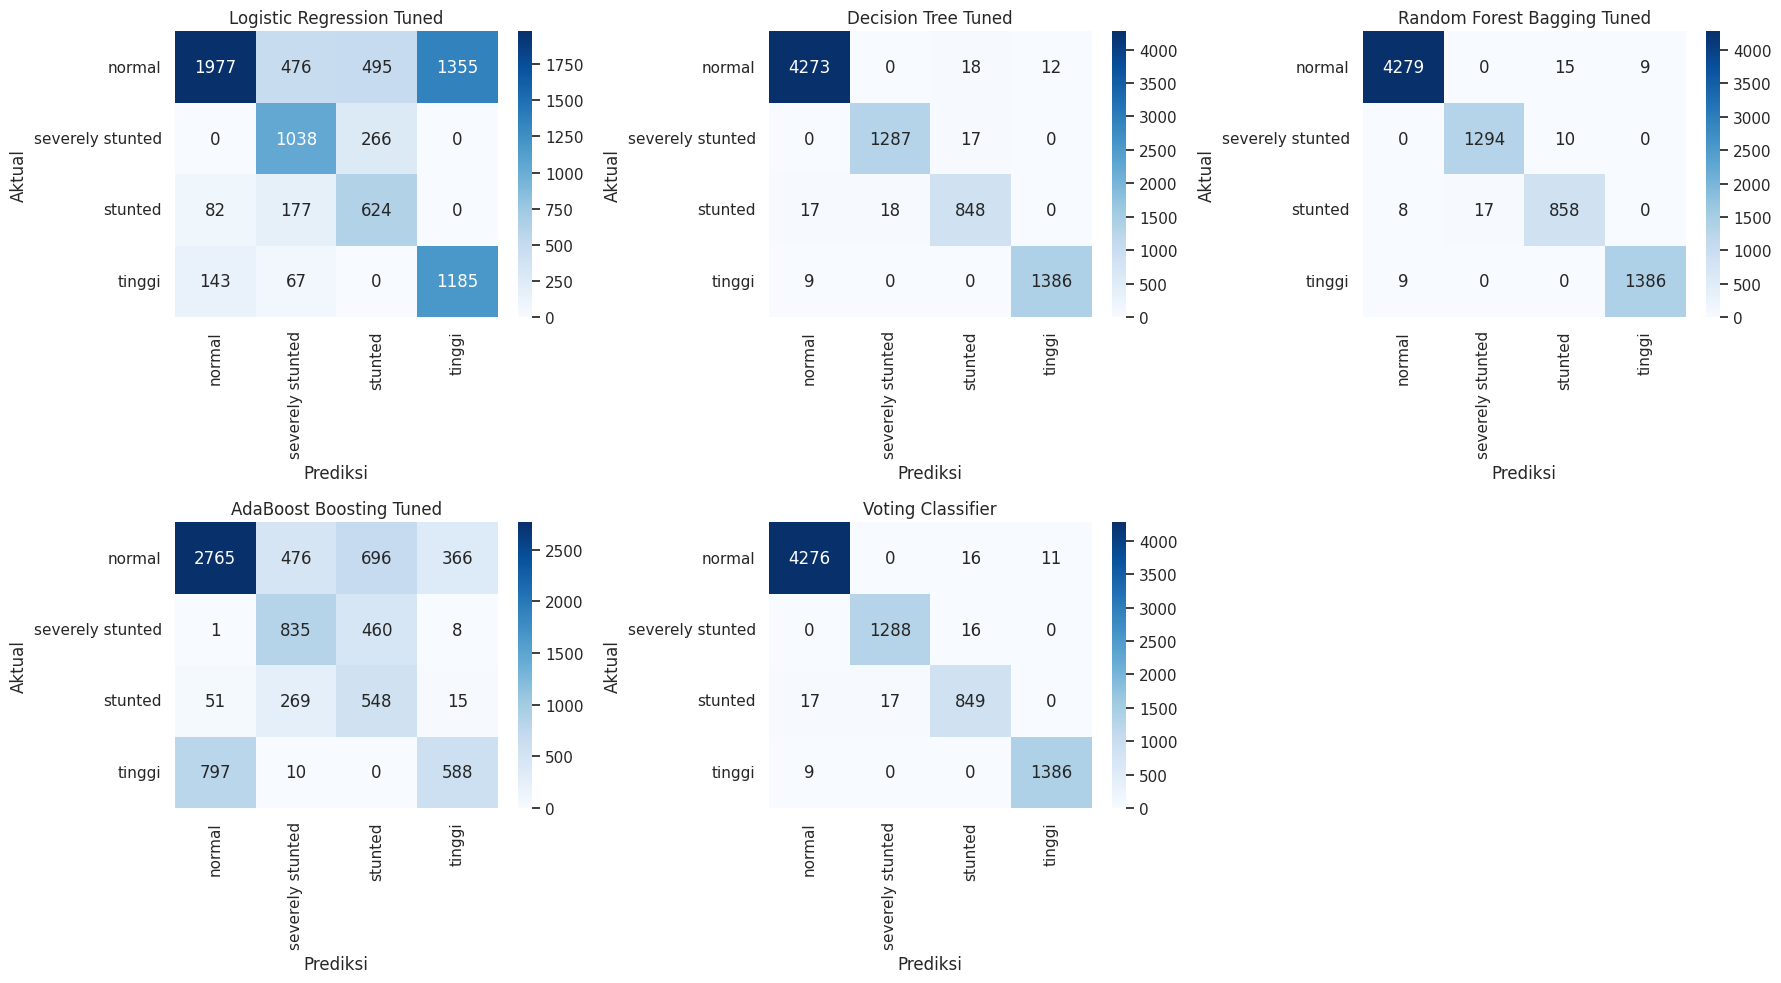

In [ ]:
plt.figure(figsize=(18, 10))

for i, (name, model) in enumerate(models.items(), 1):
    preds = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, preds)

    plt.subplot(2, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_status.classes_, yticklabels=le_status.classes_)
    plt.title(name)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')

plt.tight_layout()
plt.show()


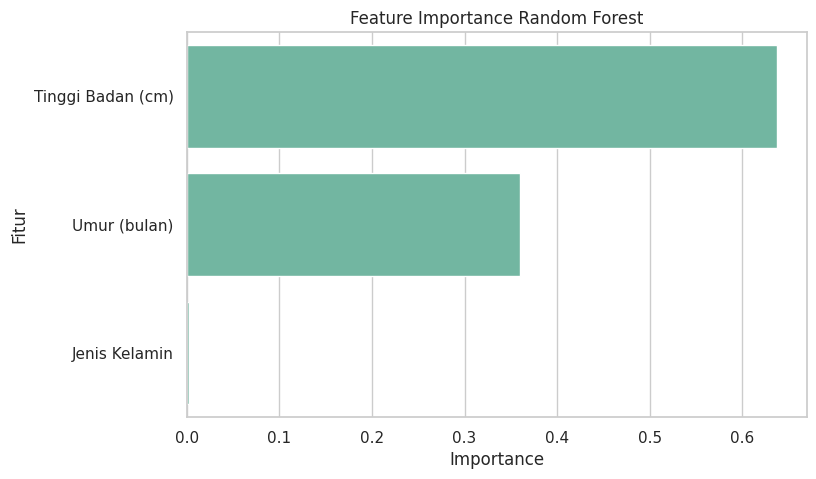

,Fitur,Importance
2,Tinggi Badan (cm),0.637567
0,Umur (bulan),0.360078
1,Jenis Kelamin,0.002355


In [ ]:
if hasattr(best_rf, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Fitur': X_train_res.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='Importance', y='Fitur')
    plt.title('Feature Importance Random Forest')
    plt.show()

    display(importance_df)


In [ ]:
critical_metrics = []
critical_labels = ['stunted', 'severely stunted']

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    report = classification_report(
        y_test,
        preds,
        target_names=le_status.classes_,
        output_dict=True,
        zero_division=0
    )

    for label in critical_labels:
        critical_metrics.append({
            'Model': name,
            'Kelas': label,
            'Precision': report[label]['precision'],
            'Recall': report[label]['recall'],
            'F1-score': report[label]['f1-score']
        })

critical_metrics_df = pd.DataFrame(critical_metrics)
critical_metrics_df


,Model,Kelas,Precision,Recall,F1-score
0,Logistic Regression Tuned,stunted,0.450542,0.706682,0.550265
1,Logistic Regression Tuned,severely stunted,0.590444,0.796012,0.677988
2,Decision Tree Tuned,stunted,0.960362,0.960362,0.960362
3,Decision Tree Tuned,severely stunted,0.986207,0.986963,0.986585
4,Random Forest Bagging Tuned,stunted,0.971687,0.971687,0.971687
5,Random Forest Bagging Tuned,severely stunted,0.987033,0.992331,0.989675
6,AdaBoost Boosting Tuned,stunted,0.321596,0.620612,0.423657
7,AdaBoost Boosting Tuned,severely stunted,0.525157,0.640337,0.577056
8,Voting Classifier,stunted,0.963678,0.961495,0.962585
9,Voting Classifier,severely stunted,0.986973,0.987730,0.987351


In [ ]:
model_package = {
    'model': best_model,
    'scaler': scaler,
    'le_gender': le_gender,
    'le_status': le_status,
    'feature_columns': X_train_res.columns.tolist(),
    'model_name': best_model_name
}

with open('model_stunting.pkl', 'wb') as file:
    pickle.dump(model_package, file)

print('Model terbaik berhasil disimpan sebagai model_stunting.pkl')


Model terbaik berhasil disimpan sebagai model_stunting.pkl


In [ ]:
print('Uji prediksi model terbaik menggunakan beberapa data test:')

sample_test = X_test.head(5).copy()
sample_test_scaled = pd.DataFrame(
    scaler.transform(sample_test),
    columns=sample_test.columns,
    index=sample_test.index
)

sample_pred = best_model.predict(sample_test_scaled)

sample_result = sample_test.copy()
sample_result['Jenis Kelamin'] = le_gender.inverse_transform(sample_result['Jenis Kelamin'])
sample_result['Aktual'] = le_status.inverse_transform(y_test.loc[sample_test.index])
sample_result['Prediksi'] = le_status.inverse_transform(sample_pred)

sample_result


Uji prediksi model terbaik menggunakan beberapa data test:


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Aktual,Prediksi
2804,1,laki-laki,69.641642,tinggi,tinggi
38997,60,laki-laki,109.800000,normal,normal
24616,37,perempuan,80.800000,severely stunted,severely stunted
24872,38,laki-laki,98.700000,normal,normal
15213,21,laki-laki,87.500000,normal,normal


Catatan evaluasi: skor model yang sangat tinggi perlu dijelaskan dengan hati-hati. Fitur umur, jenis kelamin, dan tinggi badan memang merupakan variabel utama untuk menentukan status gizi berdasarkan tinggi badan menurut umur. Karena itu, hubungan fitur dan target pada dataset ini sangat kuat.


## ANGGOTA 6 - JUL
### Deployment Streamlit
Model yang digunakan untuk deployment adalah `model_stunting.pkl` (model terbaik)


# **Berikut ini Link websitenya : https://prediksi-stunting-gizi-balita.streamlit.app/**